## Analysis of the simulations output



Analysis of the files obtained in JWST server, using 500 combinations of parameters --> 450 in total, because 50 for a=1 (W(t)=0) were not inlcuded in the massive execution.

- Tmax = 5000 generations
- Number of replicates = 10000 replicates (one round)
- Size of array = 19 spacers

### CSV file

In [1]:
import glob
import pandas as pd
import re 
import os

def load_file(file_path):
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5) 
    return data

folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/"
file_pattern = r"OutputFile_*.txt"
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Creating an output file to keep the age of the last spacer
input_file = "ANALYSIS/age_data.txt"

with open(input_file, "w") as f:
    f.write("age_last_spacer\ta\tpEndemic\tg\n")

    for file_path in file_paths:
        data = load_file(file_path)  
        age = data['age']
        file_name = os.path.basename(file_path) 
        match = re.search(r'(\d+\.\d+)_(\d+\.\d+)_(\d+\.\d+)', file_name)
        if match:
            a, g, pEndemic = map(float, match.groups())
            f.write(f"{age[9]}\t{a}\t{pEndemic}\t{g}\n")
            
output_file = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/age_data.csv"
df = pd.read_csv(input_file, sep="\t", engine="python")
df.to_csv(output_file, index=False)  

print(f"Results saved in {output_file}")

Results saved in /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/age_data.csv


In [2]:
open("/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/age_data.csv", "r")

<_io.TextIOWrapper name='/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/age_data.csv' mode='r' encoding='UTF-8'>

In [3]:
df = pd.read_csv('/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/age_data.csv',engine='python')

In [4]:
# First inspection of the data (dimensions, aspect, missing values)
data_info = {
    "shape": df.shape,
    "head": df.head(),
    "missing_values": df.isnull().sum().sum()
}
data_info

{'shape': (450, 4),
 'head':    age_last_spacer     a  pEndemic     g
 0          17.0260  0.36       0.1   5.0
 1          26.1890  0.77       0.8   5.0
 2          13.5516  0.10       0.4  10.0
 3          17.2729  0.60       0.5  10.0
 4          17.3475  0.28       0.3  20.0,
 'missing_values': 0}

### Histogram

minimum age: 10.0772
maximum age: 62.9182


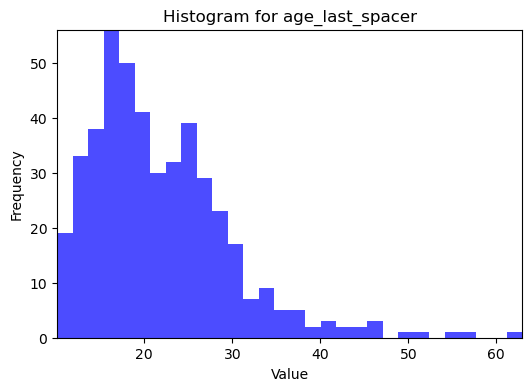

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# x and y limits
x_min, x_max = df["age_last_spacer"].min(), df["age_last_spacer"].max()
counts, _ = np.histogram(df["age_last_spacer"].dropna(), bins=30)
y_max = counts.max()  
print("minimum age:",x_min)
print("maximum age:",x_max)
    # Create and show histogram
plt.figure(figsize=(6, 4))
plt.hist(df["age_last_spacer"].dropna(), bins=30, alpha=0.7, color="blue")
plt.title(f"Histogram for age_last_spacer")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.xlim(x_min, x_max)
plt.ylim(0, y_max)
plt.show()

### Boxplot

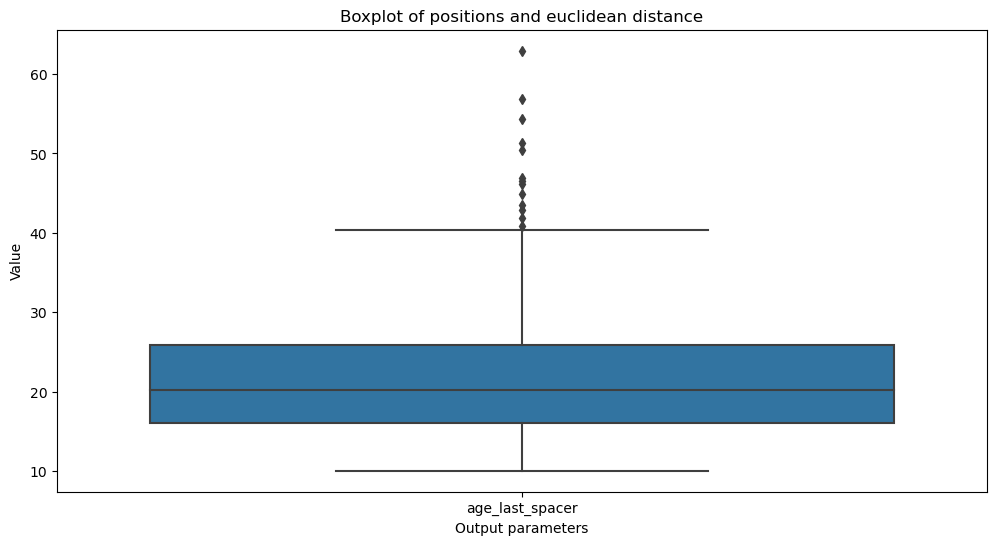

In [6]:
import seaborn as sns

df_1 = pd.DataFrame(columns=["age_last_spacer"], data=df)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_1)
plt.title("Boxplot of positions and euclidean distance")
plt.xlabel("Output parameters")
plt.ylabel("Value")
plt.show()

### Heatmap (sorted inputs)

In [7]:
from sklearn import preprocessing
max_abs_scaler = preprocessing.MaxAbsScaler()

**Sorted by a**

In [8]:
df['a'] = df['a'].astype(float)  
sorted_df_a = df.sort_values(by=['a','pEndemic','g'])
data_Sc = pd.DataFrame(max_abs_scaler.fit_transform(sorted_df_a), columns=df.columns)

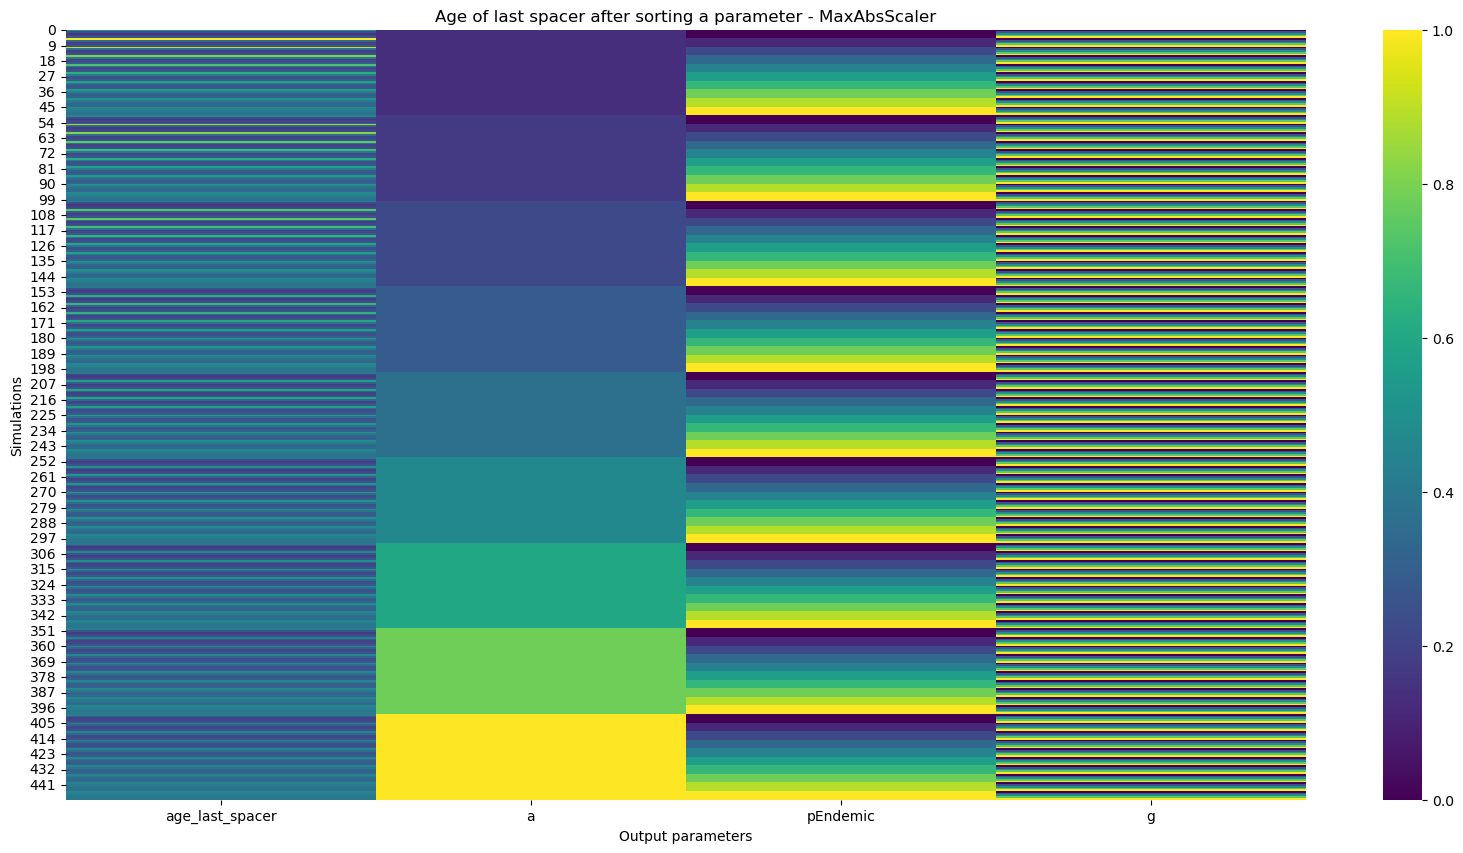

In [9]:
plt.figure(figsize=(20, 10))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Age of last spacer after sorting a parameter - MaxAbsScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

**Sorted by pEndemic**

In [10]:
df['pEndemic'] = df['pEndemic'].astype(float)  
sorted_df_pEnd = df.sort_values(by=['pEndemic','g','a'])
data_Sc = pd.DataFrame(max_abs_scaler.fit_transform(sorted_df_pEnd), columns=df.columns)

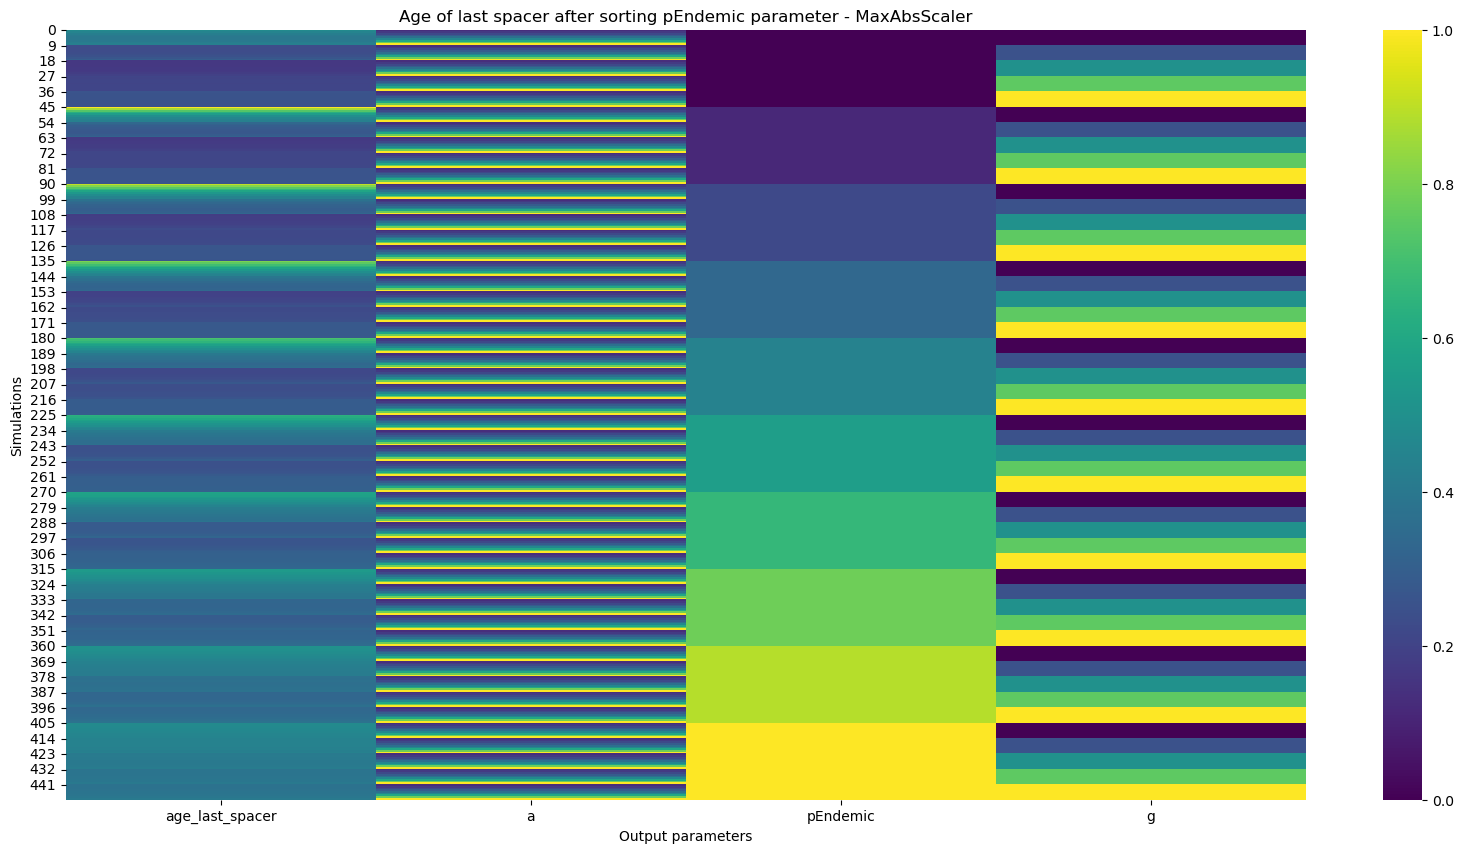

In [11]:
plt.figure(figsize=(20, 10))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Age of last spacer after sorting pEndemic parameter - MaxAbsScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

**Sorted by g**

In [12]:
df['g'] = df['g'].astype(float)  
sorted_df_g = df.sort_values(by=['g','a','pEndemic'])
data_Sc = pd.DataFrame(max_abs_scaler.fit_transform(sorted_df_g), columns=df.columns)

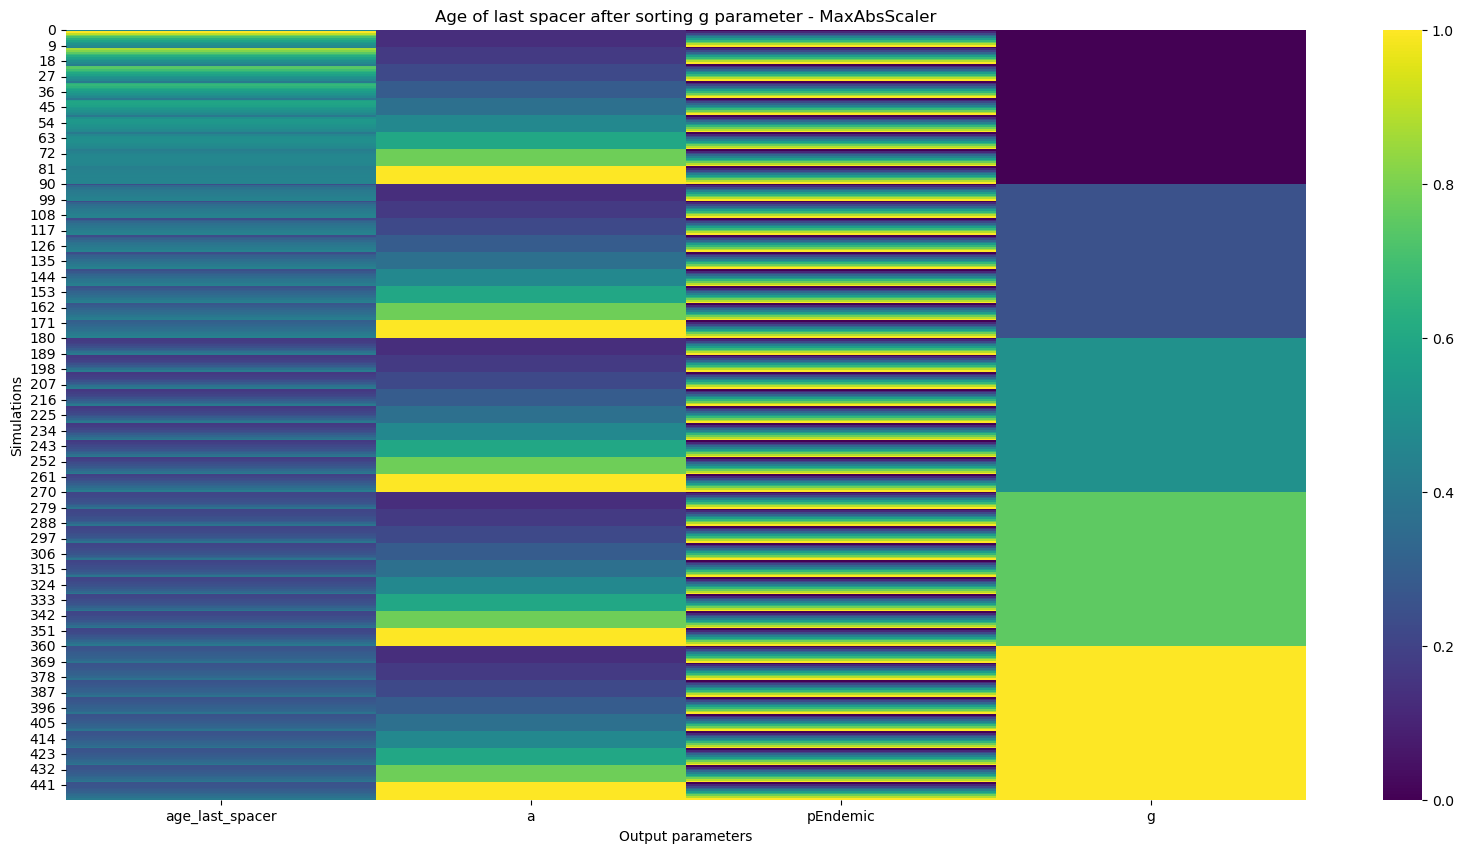

In [13]:
plt.figure(figsize=(20, 10))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Age of last spacer after sorting g parameter - MaxAbsScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

### Heatmap (sorted output)

In [14]:
df['age_last_spacer'] = df['age_last_spacer'].astype(float)  
sorted_df_age = df.sort_values(by=['age_last_spacer'])
data_Sc = pd.DataFrame(max_abs_scaler.fit_transform(sorted_df_age), columns=df.columns)

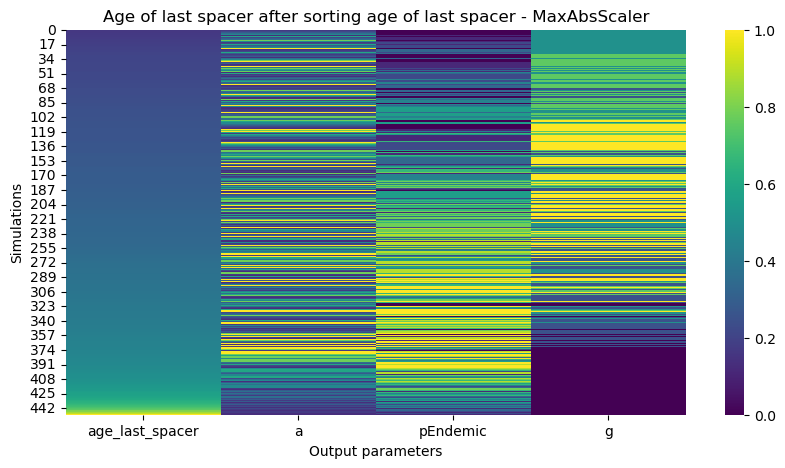

In [15]:
plt.figure(figsize=(10, 5))
sns.heatmap(data_Sc, cmap="viridis", cbar=True)
plt.title("Age of last spacer after sorting age of last spacer - MaxAbsScaler")
plt.xlabel("Output parameters")
plt.ylabel("Simulations")
plt.show()

### Simulations graphs (with different colors)

**a in the x axis, g is the color, pEndemic the transparency**

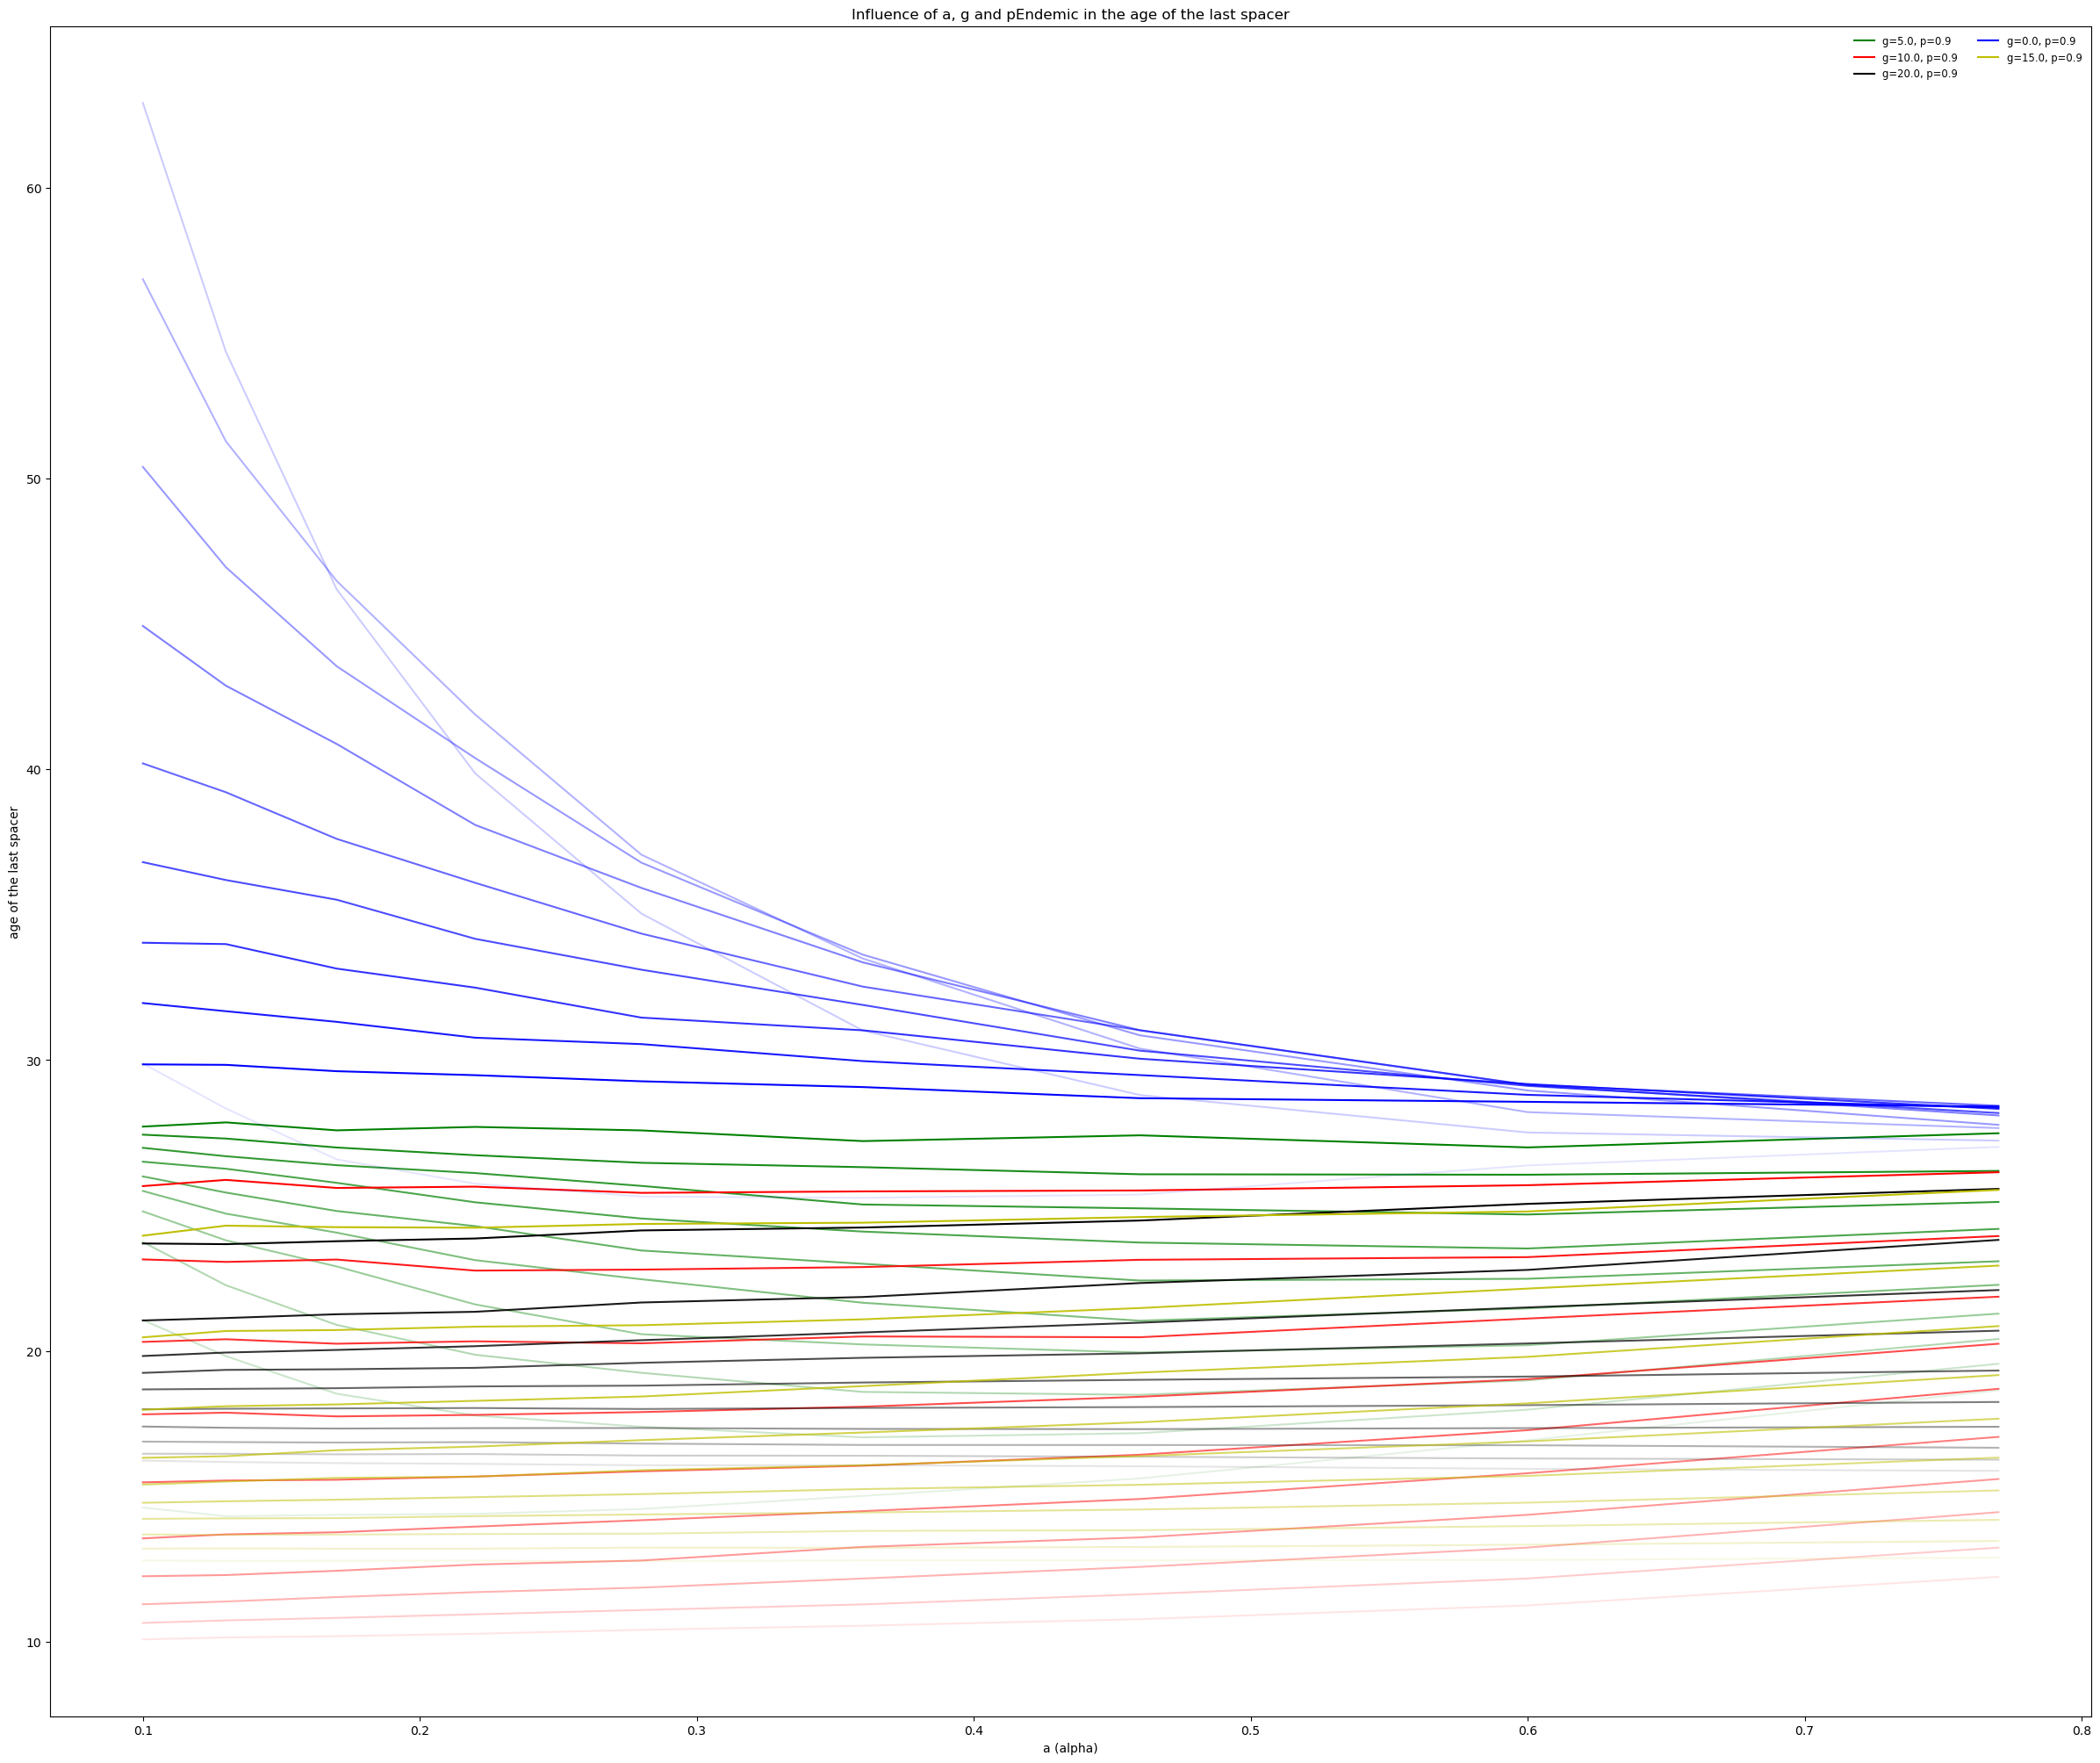

In [16]:
color_dict = {0: 'b', 5: 'g', 10: 'r', 15: 'y', 20: 'k'}

plt.figure(figsize=(30, 25))
for g_val in df['g'].unique():
    for p_val in df['pEndemic'].unique():
        subset = df[(df['g'] == g_val) & (df['pEndemic'] == p_val)].sort_values(by='a')
        plt.plot(subset['a'], subset['age_last_spacer'], color=color_dict[g_val], alpha=0.1 + p_val, label=f"g={g_val}, p={p_val}" if p_val == 0.9 else "")

plt.xlabel("a (alpha)")
plt.ylabel("age of the last spacer")
plt.title("Influence of a, g and pEndemic in the age of the last spacer")
plt.legend(loc='upper right', fontsize='small', ncol=2, frameon=False)
plt.show()

**pEndemic in the x axis, g is the color, a the transparency**

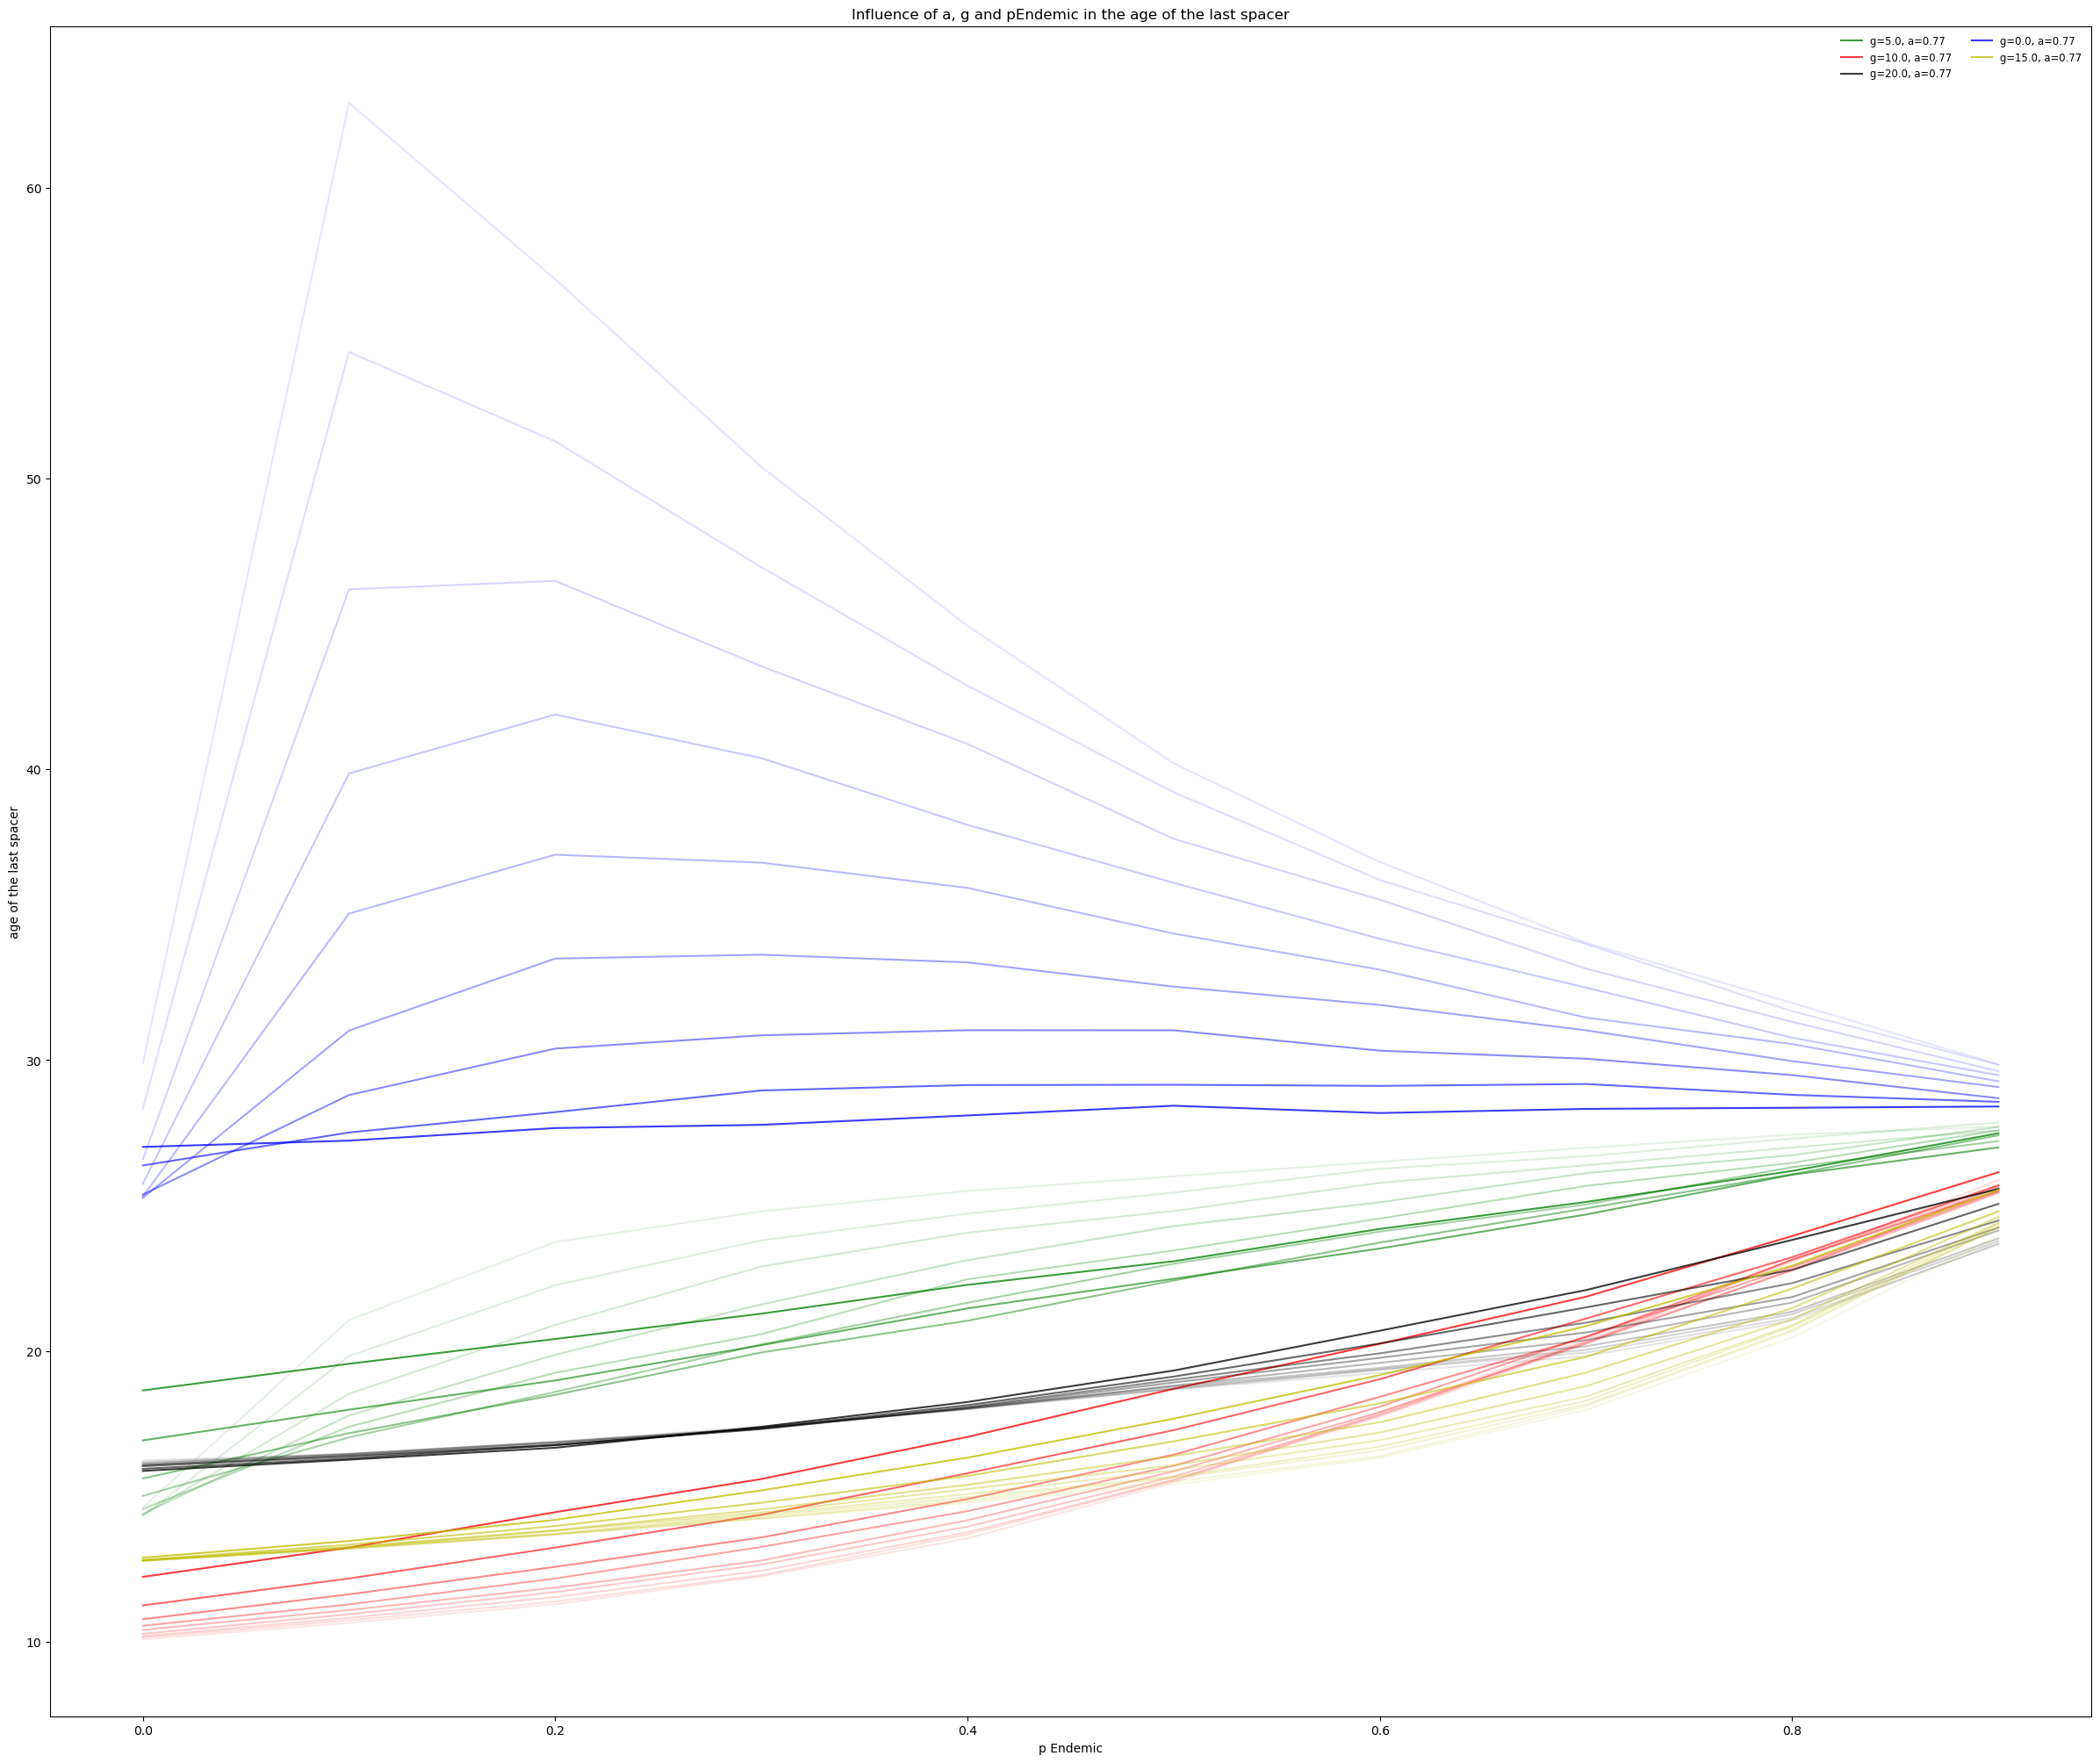

In [17]:
color_dict = {0: 'b', 5: 'g', 10: 'r', 15: 'y', 20: 'k'}

plt.figure(figsize=(30, 25))
for g_val in df['g'].unique():
    for a_val in df['a'].unique():
        subset = df[(df['g'] == g_val) & (df['a'] == a_val)].sort_values(by='pEndemic')
        plt.plot(subset['pEndemic'], subset['age_last_spacer'], color=color_dict[g_val], alpha= a_val, label=f"g={g_val}, a={a_val}" if a_val == 0.77 else "")

plt.xlabel("p Endemic")
plt.ylabel("age of the last spacer")
plt.title("Influence of a, g and pEndemic in the age of the last spacer")
plt.legend(loc='upper right', fontsize='small', ncol=2, frameon=False)
plt.show()

**g in the x axis, a is the color, pEndemic the transparency**

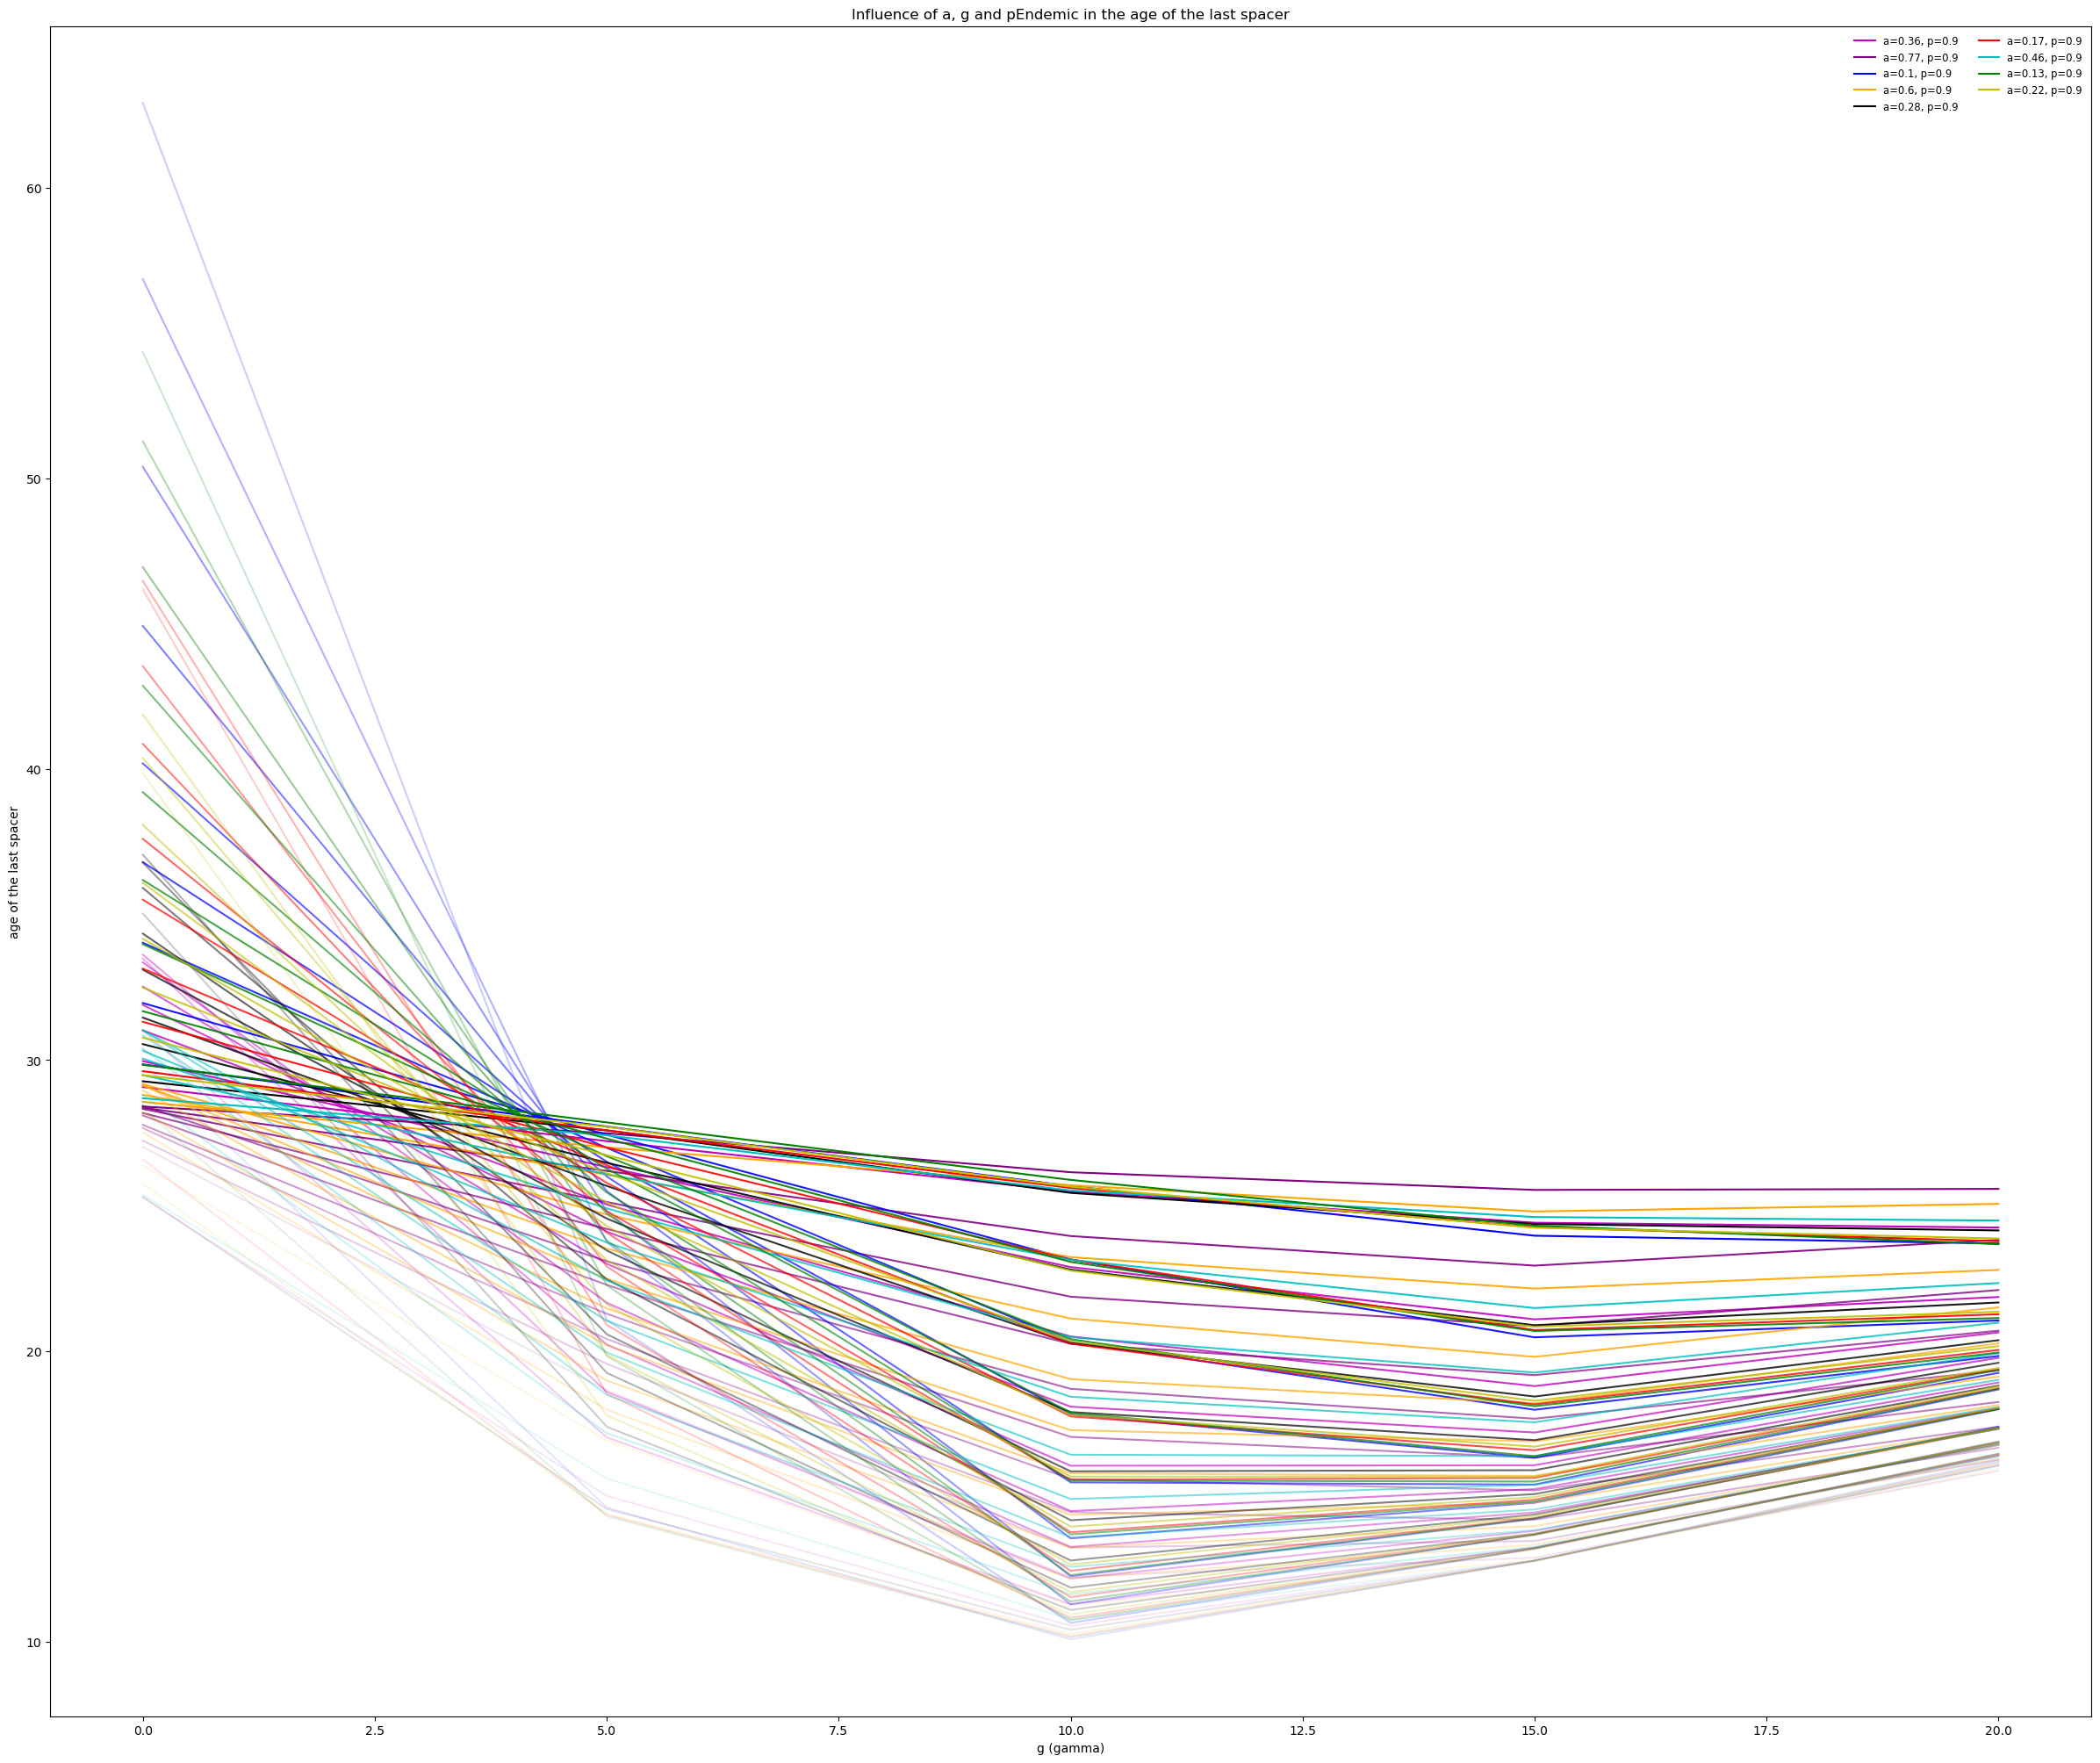

In [18]:
color_dict = {0.10: 'b', 0.13: 'g', 0.17: 'r', 0.22: 'y', 0.28: 'k', 0.36: 'm', 0.46: 'c', 0.60: 'orange', 0.77: 'purple'}
plt.figure(figsize=(30, 25))
for a_val in df['a'].unique():
    for p_val in df['pEndemic'].unique():
        subset = df[(df['a'] == a_val) & (df['pEndemic'] == p_val)].sort_values(by='g')
        plt.plot(subset['g'], subset['age_last_spacer'], color=color_dict[a_val], alpha=0.1 + p_val, label=f"a={a_val}, p={p_val}" if p_val == 0.9 else "")

plt.xlabel("g (gamma)")
plt.ylabel("age of the last spacer")
plt.title("Influence of a, g and pEndemic in the age of the last spacer")
plt.legend(loc='upper right', fontsize='small', ncol=2, frameon=False)
plt.show()

### Interpretation

**Before looking at the results**

We expect that the three parameters have an impact on the final spacer age:
- pEndemic: as pEndemic is larger, the number of endemic spacers in our simulation is also bigger. This means there is more selection for endemic spacers, and overall the spacers in the array should be older, because the endemic spacers are the ones that can last in the CRISPR array without being removed. The age of the last spacer will therefore be a big number if the pEndemic is close to 0.9.
- a: as a is larger, the number of endemic spacers that will last in the CRISPR array decreases. The fitness for endemic spacers is 1-a, so for a bigger a, the spacers in the array will be younger, including the last spacer.
- g: as g is bigger, the time when the selection for endemic spacers starts increases. This means they have less time to grow old. So, as g is bigger, the spacers will be younger, and the age of the last spacer will be lower. However, considering the number of generations we did for these simulations is 5000 generations, starting the selection in t = 20 generations should not have a very big impact. 

**Distribution of the data**
- The minimum age of the last spacer is 88.5748.
- The maximum age of the lastspacer is 580.367.
- Approximatelythe 25% of the simulations have an age of the last spacer around 190 generations.
- There is a high number of outliers, specially for values close to the maximum age.

**According to what we expected**
- As a is larger, the age of the last spacer is lower. The same happens with g, but is has a smaller impact on the age of the last spacer.
- For pEndemic=0, the values of the age of the last spacer are low.

**Not expected**
- For pEndemic=0.9, the values of age_last_spacer are aroung 290, not close to the maximum.
- For pEndemic around 0.5 is when the biggest values of age_last_spacer are obtained.
- The maximum of the age of the last spacer is obtained for pEndemic=0.1. 
- We cannot say therefore that as pEndemic is bigger, the age_last_spacer is also bigger.
- What is happening is that the age reaches the maximum when there are endemic spacers, but not too many to compete between them.

**Converging behaviour**

As we can see from the color graphs at the end of the jupyter notebook, the largest a and pEndemic make age_last_spacer converge to the medium value of aroun 190-200 generations.

**Lineal behaviour for g**

When we plot g in the x axis in these colorful graphs, we can see that the way age_last_spacer decreases as g increases is lineal. In this case, the other parameters affect these ways:
- For pEndemic close to 0.9, the parameter g has almost no impact on age_last_spacer (we can see the slope is really low). It seems the steepest slopes are obtained with pEndemic around 0.1.
- The parameter a places the straight lines higher or lower, but it does not appear to have a great influence on the slope (in the way age_last_spacer decreases more or less with g).